# Exploración de datos — Reingreso hospitalario a 30 días

**Pregunta de negocio** : ¿Qué pacientes diabéticos van a reingresar al hospital dentro de los 30 días siguientes al alta?

De la respuesta depende una decisión concreta: a qué pacientes se les agenda control de seguimiento antes del alta, dado que la capacidad de seguimiento es limitada.

Los datos provienen de [Diabetes 130-US Hospitals for Years 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (UCI, CC BY 4.0) y comprenden 101 766 encuentros hospitalarios descritos por 50 columnas.

## 1. Carga de datos

El archivo presenta dos particularidades que hacen que una lectura estándar con pandas produzca conteos equivocados de datos ausentes. Conviene resolverlas antes de calcular cualquier estadística, porque el error se propaga en silencio.

En **1.1** se verifica que el archivo en disco corresponde al que declara el repositorio. En **1.2** se comparan los conteos obtenidos con la lectura por defecto y con una lectura ajustada, para dimensionar la diferencia. En **1.3** se define la función de carga que utilizarán las demás secciones. En **1.4** se validan la forma, los tipos y los conteos del resultado.

La primera celda fija las rutas del proyecto y las opciones de presentación de pandas.

In [1]:
from pathlib import Path
import hashlib

import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CRUDOS = RAIZ / "data" / "raw" / "diabetic_data.csv"
MANIFIESTO = RAIZ / "docs" / "soportes" / "checksums-datos-crudos.txt"

FILAS_ESPERADAS = 101_766
COLUMNAS_ESPERADAS = 50

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print(f"Raiz del proyecto: {RAIZ}")
print(f"Archivo:           {CRUDOS.relative_to(RAIZ)}  ({CRUDOS.stat().st_size / 1e6:.1f} MB)")

Raiz del proyecto: /Users/katerinearias/Documents/microproyecto-desarrollo-soluciones
Archivo:           data/raw/diabetic_data.csv  (19.2 MB)


In [2]:
import matplotlib.pyplot as plt

# Misma paleta que las figuras del reporte, para que ambas se lean como un solo sistema.
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
SERIE = "#2a78d6"
SERIE_2 = "#c8532b"
SERIE_TENUE = "#a8c8ec"
REFERENCIA = "#9a9992"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE,
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "text.color": TINTA,
    "axes.labelcolor": TINTA_2,
    "xtick.color": TINTA_2,
    "ytick.color": TINTA_2,
    "axes.edgecolor": "#dcdbd4",
    "axes.linewidth": 0.8,
    "figure.dpi": 130,
})


def limpiar(ax, horizontal=False):
    """Deja solo el eje que sostiene el dato; el resto se vuelve recesivo."""
    for lado in ("top", "right", "left" if not horizontal else "bottom"):
        ax.spines[lado].set_visible(False)
    ax.tick_params(length=0)
    if horizontal:
        ax.xaxis.set_visible(False)
        ax.grid(axis="x", color="#eceae4", linewidth=0.8, zorder=0)
    else:
        ax.grid(axis="y", color="#eceae4", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


def linea_referencia(ax, valor, etiqueta="Tasa general 11,2 %"):
    """Marca la tasa de reingreso del conjunto, que da sentido a cada barra."""
    ax.axhline(valor, color=REFERENCIA, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
    ax.text(ax.get_xlim()[1], valor, f" {etiqueta}", va="center", ha="left",
            fontsize=7.5, color=REFERENCIA)


def pct(x):
    return f"{x:.1f} %".replace(".", ",")

### 1.1 Verificación del archivo

El repositorio guarda las huellas SHA-256 de los datos crudos en `docs/soportes/checksums-datos-crudos.txt`. DVC valida su propio hash al descargar, pero el manifiesto cumple una función adicional: permite que alguien que obtenga el conjunto directamente de UCI confirme que trabaja sobre los mismos bytes, sin necesidad de instalar DVC.

La celda siguiente lee el manifiesto, calcula la huella del archivo local y compara ambos valores.

In [3]:
def verificar_integridad(ruta: Path = CRUDOS) -> bool:
    """Compara la huella SHA-256 del archivo con la declarada en el manifiesto."""
    esperados = {}
    for linea in MANIFIESTO.read_text().splitlines():
        if linea.startswith("#") or not linea.strip():
            continue
        huella, archivo = linea.split(maxsplit=1)
        esperados[archivo.strip()] = huella

    relativa = str(ruta.relative_to(RAIZ))
    real = hashlib.sha256(ruta.read_bytes()).hexdigest()
    return real == esperados[relativa]


ok = verificar_integridad()
print(f"La huella SHA-256 {'coincide' if ok else 'NO coincide'} con el manifiesto.")

La huella SHA-256 coincide con el manifiesto.


### 1.2 Lectura por defecto frente a lectura ajustada

`pandas.read_csv` sin argumentos produce conteos incorrectos de datos ausentes en este archivo, por dos motivos independientes:

- El archivo marca los datos ausentes con el símbolo `?`. Como pandas espera campos vacíos o la cadena `NA`, no los reconoce, y `isna()` devuelve cero en columnas donde efectivamente falta información.
- Las columnas `A1Cresult` y `max_glu_serum` emplean el valor `None` para indicar que el examen no fue ordenado. Ese valor figura en la lista de nulos que pandas aplica por defecto, de modo que un registro clínico válido termina contabilizado como dato faltante.

Las dos celdas siguientes leen el archivo de ambas maneras y comparan los conteos columna por columna. La primera construye la tabla de diferencias; la segunda resume la magnitud total.

In [4]:
por_defecto = pd.read_csv(CRUDOS)
ajustada = pd.read_csv(CRUDOS, dtype=str, keep_default_na=False, na_values=[])
ajustada = ajustada.replace("?", pd.NA)

comparacion = pd.DataFrame({
    "por_defecto": por_defecto.isna().sum(),
    "ajustada": ajustada.isna().sum(),
})
comparacion["diferencia"] = comparacion["ajustada"] - comparacion["por_defecto"]
comparacion = comparacion[comparacion["diferencia"] != 0].sort_values("diferencia")
comparacion

,por_defecto,ajustada,diferencia
max_glu_serum,96420,0,-96420
A1Cresult,84748,0,-84748
diag_1,0,21,21
diag_2,0,358,358
diag_3,0,1423,1423
race,0,2273,2273
payer_code,0,40256,40256
medical_specialty,0,49949,49949
weight,0,98569,98569


In [5]:
sobrecontados = -comparacion.loc[comparacion["diferencia"] < 0, "diferencia"].sum()
no_detectados = comparacion.loc[comparacion["diferencia"] > 0, "diferencia"].sum()

print(f"Registros validos contados como ausentes : {sobrecontados:>8,}")
print(f"Datos ausentes no detectados             : {no_detectados:>8,}")
print(f"Total de filas del conjunto              : {len(por_defecto):>8,}")

Registros validos contados como ausentes :  181,168
Datos ausentes no detectados             :  192,849
Total de filas del conjunto              :  101,766


Las diferencias negativas corresponden a registros válidos que la lectura por defecto contabiliza como ausentes. Afectan solo a las dos columnas de exámenes de laboratorio, y el motivo es el mismo en ambas. Que un médico ordene o no la hemoglobina glicosilada constituye información relevante; de hecho, es la hipótesis central del artículo original publicado sobre este conjunto de datos.

Las diferencias positivas corresponden a datos ausentes que la lectura por defecto no detecta. Son siete columnas. `weight` presenta el caso más severo, con 96,9 % de registros sin valor. `medical_specialty` y `payer_code` se sitúan entre 40 % y 49 %, proporción suficiente para condicionar su uso posterior en el modelo.

### 1.3 Función de carga

La lectura se ajusta mediante tres argumentos de `read_csv`:

| Argumento | Efecto |
|---|---|
| `keep_default_na=False` | pandas deja de aplicar su lista de valores nulos, de modo que `None` se conserva como texto |
| `na_values=[]` | no se incorpora ningún valor adicional a esa lista |
| `dtype=str` | se desactiva la inferencia automática de tipos |

El tercer argumento resulta necesario por las columnas de diagnóstico. Los códigos están registrados en formato ICD-9 y algunos incluyen decimales (`250.83`) mientras otros comienzan por letra (`V57`, `E878`). Bajo inferencia automática la columna se interpreta como numérica y los códigos alfanuméricos se pierden.

Leído el archivo, los `?` se sustituyen por `pd.NA`. La sustitución puede aplicarse sobre todo el DataFrame porque `?` aparece únicamente en siete columnas y en ninguna representa un valor válido.

Los tipos se asignan de manera explícita. Ocho columnas admiten operaciones aritméticas y se convierten a entero. Las restantes permanecen como texto, incluidas `encounter_id` y `patient_nbr`, que son identificadores, y las tres columnas terminadas en `_id`, que contienen códigos de categoría donde el orden numérico carece de significado.

La celda siguiente define `cargar()` y muestra las primeras filas del resultado.

In [6]:
AUSENTE = "?"

# Unicas columnas sobre las que tiene sentido operar aritmeticamente.
ENTERAS = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]


def cargar(ruta: Path = CRUDOS, verificar: bool = True) -> pd.DataFrame:
    """Lee el archivo crudo con los ajustes descritos en 1.3."""
    if verificar and not verificar_integridad(ruta):
        raise ValueError(f"{ruta.name} no coincide con la huella declarada")

    df = pd.read_csv(ruta, dtype=str, keep_default_na=False, na_values=[])
    df = df.replace(AUSENTE, pd.NA)

    for col in ENTERAS:
        # errors='raise' evita que un valor no numerico pase inadvertido como NaN.
        df[col] = pd.to_numeric(df[col], errors="raise").astype("int64")

    return df


df = cargar()
df.head(3)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


### 1.4 Validación

Se aplican cinco comprobaciones sobre el DataFrame resultante: número de filas, número de columnas, ausencia de valores faltantes en las dos columnas de exámenes, ausencia de `?` residuales y tipo entero en las ocho columnas numéricas.

La tercera comprobación verifica de forma directa el ajuste descrito en 1.3. Si `A1Cresult` o `max_glu_serum` presentaran valores ausentes, significaría que `None` volvió a interpretarse como nulo.

In [7]:
def verificar_carga(df: pd.DataFrame) -> list[str]:
    """Devuelve la lista de comprobaciones fallidas. Vacia si todas pasan."""
    fallas = []

    if len(df) != FILAS_ESPERADAS:
        fallas.append(f"filas: {len(df):,} (se esperaban {FILAS_ESPERADAS:,})")
    if df.shape[1] != COLUMNAS_ESPERADAS:
        fallas.append(f"columnas: {df.shape[1]} (se esperaban {COLUMNAS_ESPERADAS})")

    for col in ("A1Cresult", "max_glu_serum"):
        n = int(df[col].isna().sum())
        if n:
            fallas.append(f"{col}: {n:,} valores ausentes, deberia tener 0")

    quedan = int((df == AUSENTE).sum().sum())
    if quedan:
        fallas.append(f"quedan {quedan:,} celdas con '{AUSENTE}'")

    for col in ENTERAS:
        if not pd.api.types.is_integer_dtype(df[col]):
            fallas.append(f"{col}: tipo {df[col].dtype}, se esperaba entero")

    return fallas


fallas = verificar_carga(df)
for f in fallas:
    print(f"Fallo: {f}")

if not fallas:
    print("Las cinco comprobaciones pasan.")
    print()
    print(f"  {len(df):,} filas y {df.shape[1]} columnas")
    print(f"  {len(ENTERAS)} columnas enteras, {df.shape[1] - len(ENTERAS)} de texto")
    print(f"  {int(df.isna().sum().sum()):,} valores ausentes en total")

Las cinco comprobaciones pasan.

  101,766 filas y 50 columnas
  8 columnas enteras, 42 de texto
  192,849 valores ausentes en total


## 2. Estructura del conjunto

Antes de examinar el contenido de las variables conviene establecer sobre qué se está trabajando: qué representa cada fila, si hay registros repetidos y qué forma tiene el conjunto en términos generales.

En **2.1** se describen las dimensiones y la composición por tipo de dato. En **2.2** se identifica la unidad de análisis, distinguiendo entre encuentros hospitalarios y pacientes. En **2.3** se comprueba la existencia de registros duplicados. En **2.4** se revisa el número de valores distintos por columna, que anticipa decisiones de codificación posteriores.

### 2.1 Dimensiones y tipos

La celda siguiente reporta el número de filas y columnas, y agrupa las columnas según el tipo asignado en la carga.

In [8]:
print(f"Filas    : {len(df):,}")
print(f"Columnas : {df.shape[1]}")
print()

enteras = [c for c in df.columns if pd.api.types.is_integer_dtype(df[c])]
texto = [c for c in df.columns if c not in enteras]

print(f"Columnas enteras ({len(enteras)}):")
for c in enteras:
    print(f"  {c}")
print()
print(f"Columnas de texto: {len(texto)}")

Filas    : 101,766
Columnas : 50

Columnas enteras (8):
  time_in_hospital
  num_lab_procedures
  num_procedures
  num_medications
  number_outpatient
  number_emergency
  number_inpatient
  number_diagnoses

Columnas de texto: 42


### 2.2 Unidad de análisis

El conjunto contiene dos identificadores. `encounter_id` identifica cada hospitalización y `patient_nbr` identifica al paciente. La relación entre ambos determina qué representa una fila y condiciona la manera de dividir los datos para entrenar y evaluar el modelo.

La celda siguiente cuenta los valores distintos de cada identificador y describe la distribución de encuentros por paciente.

In [9]:
print(f"Encuentros distintos (encounter_id) : {df['encounter_id'].nunique():,}")
print(f"Pacientes distintos (patient_nbr)   : {df['patient_nbr'].nunique():,}")
print()

encuentros_por_paciente = df["patient_nbr"].value_counts()
un_encuentro = int((encuentros_por_paciente == 1).sum())
varios = int((encuentros_por_paciente > 1).sum())
filas_repetidas = int(encuentros_por_paciente[encuentros_por_paciente > 1].sum())

print(f"Pacientes con un solo encuentro  : {un_encuentro:,}")
print(f"Pacientes con dos o mas          : {varios:,}")
print(f"Maximo de encuentros de un mismo paciente : {encuentros_por_paciente.max()}")
print()
print(f"Filas que pertenecen a pacientes repetidos : {filas_repetidas:,} "
      f"({filas_repetidas / len(df) * 100:.1f} %)")

Encuentros distintos (encounter_id) : 101,766
Pacientes distintos (patient_nbr)   : 71,518

Pacientes con un solo encuentro  : 54,745
Pacientes con dos o mas          : 16,773
Maximo de encuentros de un mismo paciente : 40

Filas que pertenecen a pacientes repetidos : 47,021 (46.2 %)


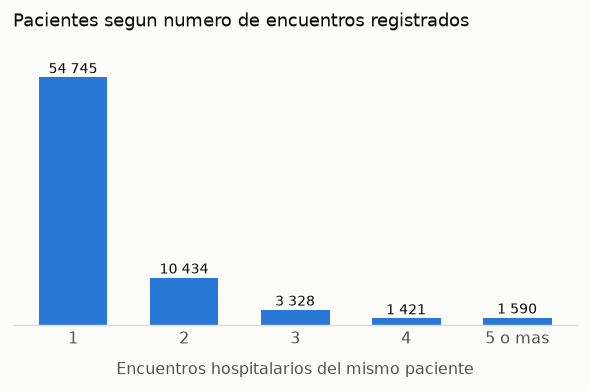

In [10]:
grupos = encuentros_por_paciente.clip(upper=5).value_counts().sort_index()
etiquetas = ["1", "2", "3", "4", "5 o mas"]

fig, ax = plt.subplots(figsize=(5.6, 2.8))
barras = ax.bar(etiquetas, grupos.values, color=SERIE, width=0.62, zorder=2)
for b, v in zip(barras, grupos.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 900,
            f"{v:,}".replace(",", " "), ha="center", fontsize=8, color=TINTA)

ax.set_title("Pacientes segun numero de encuentros registrados", fontsize=10,
             color=TINTA, loc="left", pad=10)
ax.set_xlabel("Encuentros hospitalarios del mismo paciente", labelpad=8)
ax.set_ylim(0, 62000)
ax.set_yticks([])
limpiar(ax)
ax.grid(False)
plt.show()

Cada fila corresponde a un encuentro hospitalario, no a un paciente. Los 101 766 encuentros se distribuyen entre 71 518 pacientes, de modo que 16 773 pacientes aparecen más de una vez y uno de ellos registra 40 hospitalizaciones.

El 46,2 % de las filas pertenece a pacientes con más de un encuentro. Esta proporción tiene una consecuencia directa sobre el diseño del experimento: una división aleatoria de los datos ubicaría encuentros del mismo paciente en entrenamiento y en evaluación al mismo tiempo, lo que permitiría al modelo reconocer al individuo en lugar de estimar su riesgo. La partición debe hacerse agrupando por `patient_nbr`. El punto se retoma en la sección 8.

### 2.3 Registros duplicados

Se verifican dos formas de duplicación: filas idénticas en todas sus columnas, y valores repetidos de `encounter_id`, que por definición debería ser único.

La celda siguiente cuenta ambos casos.

In [11]:
print(f"Filas identicas en las 50 columnas : {df.duplicated().sum():,}")
print(f"Valores repetidos de encounter_id  : {df['encounter_id'].duplicated().sum():,}")

Filas identicas en las 50 columnas : 0
Valores repetidos de encounter_id  : 0


No se detectan duplicados en ninguna de las dos formas. `encounter_id` funciona como clave primaria del conjunto.

### 2.4 Número de valores distintos por columna

El recuento de valores distintos permite identificar dos situaciones que condicionan el tratamiento posterior: columnas con un único valor, que no aportan información, y columnas con muchos valores distintos, que requieren agrupación antes de entrar al modelo.

La celda siguiente ordena las columnas por número de valores distintos y muestra los extremos.

In [12]:
cardinalidad = df.nunique().sort_values()

print("Columnas con menor numero de valores distintos:")
print(cardinalidad.head(8).to_string())
print()
print("Columnas con mayor numero de valores distintos:")
print(cardinalidad.tail(6).to_string())

Columnas con menor numero de valores distintos:
examide                    1
citoglipton                1
troglitazone               2
acetohexamide              2
tolbutamide                2
glipizide-metformin        2
diabetesMed                2
metformin-rosiglitazone    2

Columnas con mayor numero de valores distintos:
num_lab_procedures       118
diag_1                   716
diag_2                   748
diag_3                   789
patient_nbr            71518
encounter_id          101766


`examide` y `citoglipton` presentan un solo valor en las 101 766 filas, de modo que no aportan capacidad discriminante y pueden descartarse.

En el extremo opuesto, las tres columnas de diagnóstico contienen entre 716 y 789 códigos distintos. Codificarlas directamente generaría más de dos mil variables indicadoras, la mayoría con muy pocos casos. Los códigos ICD-9 admiten agrupación por categoría clínica, alternativa que se evalúa en la sección 6.

`encounter_id` y `patient_nbr` aparecen con la cardinalidad más alta por ser identificadores. Ninguno entra al modelo como variable predictora.

## 3. Valores faltantes

La sección 1 dejó marcados los datos ausentes con `pd.NA`. Corresponde ahora cuantificarlos y decidir qué hacer con cada columna afectada.

En **3.1** se cuantifica el volumen de datos ausentes por columna. En **3.2** se examina si el hecho de que un dato falte guarda relación con el reingreso, lo que determina si conviene imputarlo o tratarlo como una categoría propia. En **3.3** se analizan las dos columnas de exámenes de laboratorio, cuyo valor `None` no corresponde a un dato perdido. En **3.4** se consolidan las decisiones.

### 3.1 Volumen de datos ausentes

La celda siguiente cuenta los valores ausentes por columna y muestra únicamente aquellas donde el conteo es distinto de cero.

In [13]:
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

resumen = pd.DataFrame({
    "ausentes": faltantes,
    "porcentaje": (faltantes / len(df) * 100).round(1),
})
resumen

,ausentes,porcentaje
weight,98569,96.9
medical_specialty,49949,49.1
payer_code,40256,39.6
race,2273,2.2
diag_3,1423,1.4
diag_2,358,0.4
diag_1,21,0.0


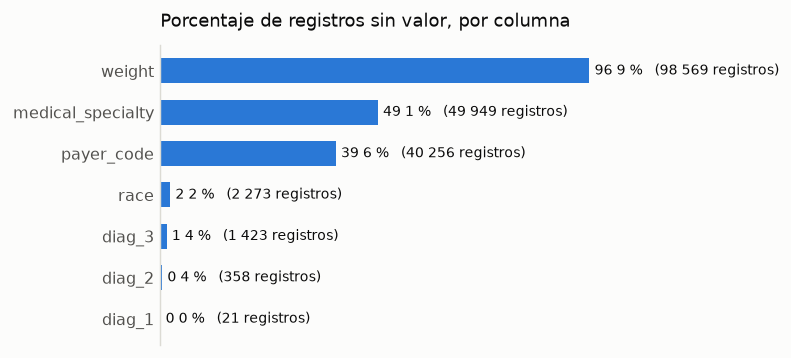

In [14]:
orden = resumen.sort_values("porcentaje")

fig, ax = plt.subplots(figsize=(5.8, 3.0))
barras = ax.barh(orden.index, orden["porcentaje"], color=SERIE, height=0.6, zorder=2)
for b, v, n in zip(barras, orden["porcentaje"], orden["ausentes"]):
    ax.text(b.get_width() + 1.2, b.get_y() + b.get_height() / 2,
            f"{pct(v)}   ({n:,}".replace(",", " ") + " registros)",
            va="center", fontsize=8, color=TINTA)

ax.set_title("Porcentaje de registros sin valor, por columna", fontsize=10,
             color=TINTA, loc="left", pad=10)
ax.set_xlim(0, 132)
limpiar(ax, horizontal=True)
plt.show()

Siete de las cincuenta columnas presentan datos ausentes. Cuarenta y tres están completas.

Las tres primeras concentran el problema. `weight` carece de valor en el 96,9 % de los registros, proporción que impide cualquier uso razonable de la variable. `medical_specialty` y `payer_code` se ubican en 49,1 % y 39,6 %, niveles que no descartan la variable pero exigen decidir cómo representar la ausencia.

Las cuatro restantes están por debajo del 2,5 % y admiten un tratamiento más simple. El caso de `diag_1`, con 21 registros, es marginal.

### 3.2 Relación entre la ausencia y el reingreso

Que un dato falte puede ser informativo. Si los registros sin valor presentan una tasa de reingreso distinta de los registros completos, la ausencia constituye información en sí misma y conviene representarla como una categoría explícita en lugar de imputarla.

La celda siguiente calcula la tasa de reingreso a 30 días separando, para cada columna afectada, los registros con dato ausente de los que tienen valor.

In [15]:
objetivo = (df["readmitted"] == "<30").astype(int)

filas = []
for col in faltantes.index:
    ausente = df[col].isna()
    filas.append({
        "columna": col,
        "n_ausentes": int(ausente.sum()),
        "reingreso_si_falta": round(objetivo[ausente].mean() * 100, 2),
        "reingreso_si_esta": round(objetivo[~ausente].mean() * 100, 2),
    })

comparativa = pd.DataFrame(filas)
comparativa["diferencia"] = (comparativa["reingreso_si_falta"]
                             - comparativa["reingreso_si_esta"]).round(2)
comparativa

,columna,n_ausentes,reingreso_si_falta,reingreso_si_esta,diferencia
0,weight,98569,11.16,11.17,-0.01
1,medical_specialty,49949,11.57,10.76,0.81
2,payer_code,40256,11.49,10.94,0.55
3,race,2273,8.27,11.23,-2.96
4,diag_3,1423,6.39,11.23,-4.84
5,diag_2,358,8.10,11.17,-3.07
6,diag_1,21,23.81,11.16,12.65


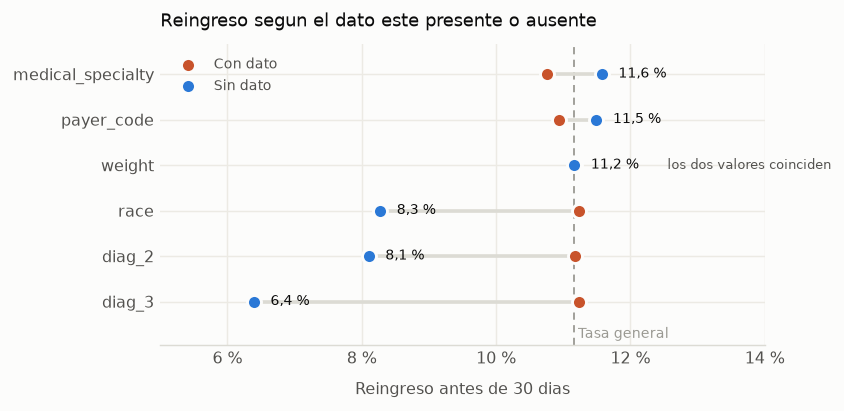

In [16]:
# Se excluye diag_1: con 21 registros ausentes su tasa no admite lectura.
d = comparativa[comparativa["n_ausentes"] >= 100].sort_values("reingreso_si_falta")

fig, ax = plt.subplots(figsize=(6.0, 3.0))
y = range(len(d))

ax.hlines(y, d["reingreso_si_esta"], d["reingreso_si_falta"],
          color="#dcdbd4", linewidth=2, zorder=1)
ax.scatter(d["reingreso_si_esta"], y, s=60, color=SERIE_2, zorder=3,
           edgecolors=SUPERFICIE, linewidths=1.6, label="Con dato")
ax.scatter(d["reingreso_si_falta"], y, s=60, color=SERIE, zorder=4,
           edgecolors=SUPERFICIE, linewidths=1.6, label="Sin dato")

ax.axvline(objetivo.mean() * 100, color=REFERENCIA, linewidth=1, linestyle=(0, (4, 3)), zorder=0)
ax.set_ylim(-0.95, len(d) - 0.35)
ax.text(objetivo.mean() * 100, -0.8, " Tasa general", fontsize=7.5, color=REFERENCIA)

for i, (_, f) in enumerate(d.iterrows()):
    ax.text(f["reingreso_si_falta"] + 0.25, i, pct(f["reingreso_si_falta"]),
            va="center", fontsize=7.5, color=TINTA)

# En weight ambos valores coinciden y un punto queda tapado por el otro.
i = list(d["columna"]).index("weight")
ax.annotate("los dos valores coinciden", xy=(12.55, i), fontsize=7,
            color=TINTA_2, va="center")

ax.set_yticks(list(y), d["columna"])
ax.set_xlabel("Reingreso antes de 30 dias", labelpad=8)
ax.set_xlim(5, 14)
ax.set_xticks([6, 8, 10, 12, 14], ["6 %", "8 %", "10 %", "12 %", "14 %"])
ax.set_title("Reingreso segun el dato este presente o ausente", fontsize=10,
             color=TINTA, loc="left", pad=10)
ax.legend(frameon=False, fontsize=8, loc="upper left", labelcolor=TINTA_2)
limpiar(ax)
ax.grid(axis="x", color="#eceae4", linewidth=0.8, zorder=0)
plt.show()

La tasa general de reingreso a 30 días en el conjunto completo es 11,2 %, y sirve de referencia para leer la tabla.

En `weight` las dos tasas son prácticamente idénticas, 11,16 % frente a 11,17 %. La ausencia no aporta información y la variable tampoco, dado que solo el 3,1 % de los registros tiene valor.

En `medical_specialty` y `payer_code` los registros sin dato presentan una tasa algo superior, con diferencias de 0,81 y 0,55 puntos porcentuales. Son diferencias pequeñas, pero se apoyan en decenas de miles de casos, de modo que la ausencia debe conservarse como categoría en lugar de imputarse.

En `race`, `diag_2` y `diag_3` los registros sin dato muestran tasas inferiores a la general. El caso de `diag_1` involucra 21 registros y no permite conclusión alguna.

### 3.3 Las columnas de exámenes de laboratorio

`A1Cresult` y `max_glu_serum` no registran datos ausentes. Su valor `None` indica que el examen no fue ordenado durante la hospitalización, lo cual constituye una decisión clínica y no una omisión de registro.

La distinción es relevante porque el artículo original sobre este conjunto de datos plantea que la medición de la hemoglobina glicosilada durante la hospitalización se asocia con menor reingreso.

La celda siguiente muestra, para cada columna, la distribución de sus valores junto con la tasa de reingreso correspondiente.

In [17]:
for col in ("A1Cresult", "max_glu_serum"):
    conteo = df[col].value_counts()
    tabla = pd.DataFrame({
        "registros": conteo,
        "porcentaje": (conteo / len(df) * 100).round(1),
        "reingreso": [round(objetivo[df[col] == v].mean() * 100, 2) for v in conteo.index],
    })
    print(f"{col}")
    print(tabla.to_string())
    print()

A1Cresult
           registros  porcentaje  reingreso
A1Cresult                                  
None           84748        83.3      11.42
>8              8216         8.1       9.87
Norm            4990         4.9       9.66
>7              3812         3.7      10.05

max_glu_serum
               registros  porcentaje  reingreso
max_glu_serum                                  
None               96420        94.7      11.09
Norm                2597         2.6      11.36
>200                1485         1.5      12.46
>300                1264         1.2      14.32



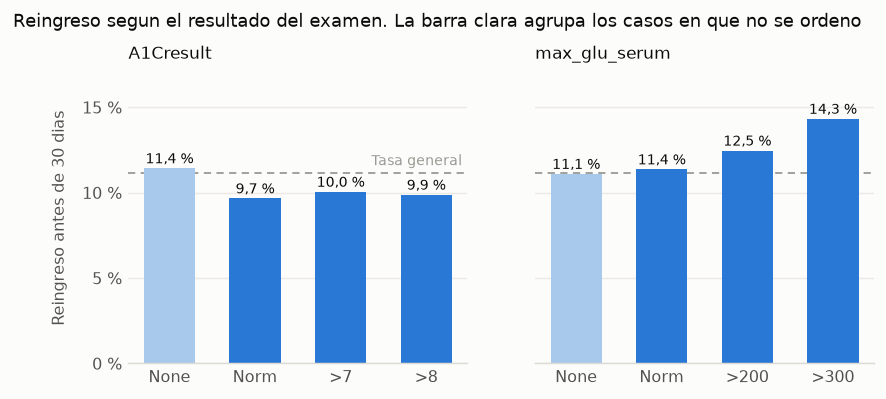

In [18]:
fig, ejes = plt.subplots(1, 2, figsize=(7.4, 2.9), sharey=True)

for ax, col, orden_valores in [
    (ejes[0], "A1Cresult", ["None", "Norm", ">7", ">8"]),
    (ejes[1], "max_glu_serum", ["None", "Norm", ">200", ">300"]),
]:
    tasas = [objetivo[df[col] == v].mean() * 100 for v in orden_valores]
    colores = [SERIE_TENUE] + [SERIE] * (len(orden_valores) - 1)

    barras = ax.bar(orden_valores, tasas, color=colores, width=0.6, zorder=2)
    for b, v in zip(barras, tasas):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3, pct(v),
                ha="center", fontsize=8, color=TINTA)

    ax.axhline(objetivo.mean() * 100, color=REFERENCIA, linewidth=1,
               linestyle=(0, (4, 3)), zorder=1)
    ax.set_title(col, fontsize=9.5, color=TINTA, loc="left", pad=8)
    ax.set_ylim(0, 17)
    limpiar(ax)

ejes[0].set_ylabel("Reingreso antes de 30 dias", labelpad=8)
ejes[0].set_yticks([0, 5, 10, 15], ["0 %", "5 %", "10 %", "15 %"])
ejes[0].text(3.42, objetivo.mean() * 100 + 0.45, "Tasa general", ha="right",
             fontsize=7.5, color=REFERENCIA)
fig.suptitle("Reingreso segun el resultado del examen. La barra clara agrupa los casos "
             "en que no se ordeno",
             fontsize=10, color=TINTA, x=0.005, ha="left", y=1.04)
plt.show()

En `A1Cresult`, los 84 748 registros sin examen ordenado presentan una tasa de reingreso de 11,42 %, superior a la de cualquiera de las tres categorías con resultado, que se sitúan entre 9,66 % y 10,05 %. El patrón es consistente con la hipótesis del artículo original: haber medido la hemoglobina glicosilada, con independencia del resultado obtenido, se asocia con un reingreso menor.

En `max_glu_serum` la relación sigue el valor del examen. La tasa asciende de 11,36 % en resultados normales a 12,46 % por encima de 200 y a 14,32 % por encima de 300. Las tres categorías con resultado reúnen 5 346 registros, el 5,3 % del conjunto.

Ninguna de las dos columnas requiere imputación. Ambas entran al modelo con `None` como una categoría más.

### 3.4 Decisiones sobre datos ausentes

La celda siguiente consolida el tratamiento definido para cada columna afectada.

In [19]:
decisiones = pd.DataFrame([
    ("weight", "96.9 %", "Descartar",
     "La ausencia no discrimina y solo el 3.1 % tiene valor"),
    ("medical_specialty", "49.1 %", "Categoria propia",
     "La ausencia se asocia a mayor reingreso sobre 49 949 registros"),
    ("payer_code", "39.6 %", "Categoria propia",
     "Mismo criterio; ademas es variable administrativa, no clinica"),
    ("race", "2.2 %", "Categoria propia",
     "No entra al modelo; se conserva para revisar sesgo por grupo"),
    ("diag_3", "1.4 %", "Categoria propia",
     "Se agrupa junto con los codigos ICD-9 en la seccion 6"),
    ("diag_2", "0.4 %", "Categoria propia", "Mismo criterio que diag_3"),
    ("diag_1", "0.0 %", "Categoria propia", "21 registros; sin efecto practico"),
], columns=["columna", "ausentes", "tratamiento", "motivo"])

decisiones

,columna,ausentes,tratamiento,motivo
0,weight,96.9 %,Descartar,La ausencia no discrimina y solo el 3.1 % tien...
1,medical_specialty,49.1 %,Categoria propia,La ausencia se asocia a mayor reingreso sobre ...
2,payer_code,39.6 %,Categoria propia,Mismo criterio; ademas es variable administrat...
3,race,2.2 %,Categoria propia,No entra al modelo; se conserva para revisar s...
4,diag_3,1.4 %,Categoria propia,Se agrupa junto con los codigos ICD-9 en la se...
5,diag_2,0.4 %,Categoria propia,Mismo criterio que diag_3
6,diag_1,0.0 %,Categoria propia,21 registros; sin efecto practico


Ninguna columna se imputa. En los tres casos con volumen apreciable la ausencia mostró relación con el reingreso, y en los cuatro restantes el volumen es demasiado bajo para que la imputación modifique el resultado. Representar la ausencia como categoría preserva esa información y evita introducir valores que no fueron observados.

`weight` es la única columna que se descarta en esta sección. `examide` y `citoglipton`, identificadas en 2.4 por tener un solo valor, se descartan por un motivo distinto.

## 4. Variable objetivo

La columna `readmitted` registra el desenlace que se busca anticipar. Antes de trabajar con ella hay que definir con precisión qué se considera un caso positivo, porque la columna admite tres valores y no dos.

En **4.1** se describe la distribución de los tres valores. En **4.2** se define la variable binaria que usará el modelo y se justifica el criterio. En **4.3** se cuantifica el desbalance resultante y se establece qué métricas de evaluación resultan adecuadas.

Los cálculos de esta sección se hacen sobre el conjunto completo. Las exclusiones se aplican en la sección 5, y allí se recalcula la proporción de positivos.

### 4.1 Distribución de la columna

La celda siguiente cuenta los registros de cada valor de `readmitted`.

In [20]:
conteo = df["readmitted"].value_counts()[["<30", ">30", "NO"]]

distribucion = pd.DataFrame({
    "registros": conteo,
    "porcentaje": (conteo / len(df) * 100).round(2),
})
distribucion

,registros,porcentaje
readmitted,,
<30,11357,11.16
>30,35545,34.93
NO,54864,53.91


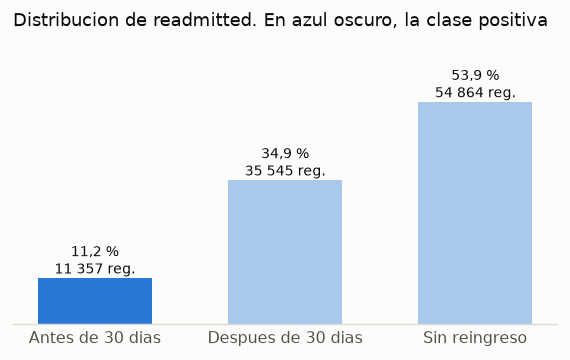

In [21]:
colores = [SERIE, SERIE_TENUE, SERIE_TENUE]

fig, ax = plt.subplots(figsize=(5.4, 2.8))
barras = ax.bar(distribucion.index, distribucion["porcentaje"],
                color=colores, width=0.6, zorder=2)
for b, v, n in zip(barras, distribucion["porcentaje"], distribucion["registros"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.2,
            pct(v) + "\n" + f"{n:,}".replace(",", " ") + " reg.",
            ha="center", fontsize=8, color=TINTA)

ax.set_title("Distribucion de readmitted. En azul oscuro, la clase positiva",
             fontsize=10, color=TINTA, loc="left", pad=10)
ax.set_xticks(range(3), ["Antes de 30 dias", "Despues de 30 dias", "Sin reingreso"])
ax.set_ylim(0, 68)
ax.set_yticks([])
limpiar(ax)
ax.grid(False)
plt.show()

La columna distingue tres desenlaces. `<30` corresponde a los pacientes que volvieron a ser hospitalizados dentro de los 30 días siguientes al alta. `>30` corresponde a quienes reingresaron después de ese plazo. `NO` corresponde a quienes no registran reingreso.

El 46,1 % de los encuentros termina en un reingreso posterior, ya sea dentro o fuera de los 30 días. El 11,16 % lo hace dentro del plazo.

### 4.2 Definición de la variable binaria

El modelo debe distinguir el reingreso temprano, no el reingreso en general. La razón es la decisión que el tablero apoya: programar control de seguimiento antes del alta. Un reingreso ocurrido ocho meses después responde a la evolución de la enfermedad y no a una falla en la transición del cuidado, de modo que no es un desenlace sobre el cual esa intervención pueda actuar.

La variable se construye entonces con `<30` como caso positivo, y `>30` junto con `NO` como casos negativos. Ambos comparten la misma interpretación desde el punto de vista de la decisión: el alta no derivó en un reingreso temprano.

La celda siguiente crea la variable y verifica que la suma de sus categorías coincide con el total de registros.

In [22]:
objetivo = (df["readmitted"] == "<30").astype(int)

positivos = int(objetivo.sum())
negativos = int((1 - objetivo).sum())

print(f"Positivos (reingreso antes de 30 dias) : {positivos:>7,}  {positivos / len(df) * 100:5.2f} %")
print(f"Negativos ('>30' y 'NO')               : {negativos:>7,}  {negativos / len(df) * 100:5.2f} %")
print(f"Suma                                   : {positivos + negativos:>7,}")

Positivos (reingreso antes de 30 dias) :  11,357  11.16 %
Negativos ('>30' y 'NO')               :  90,409  88.84 %
Suma                                   : 101,766


### 4.3 Desbalance y elección de métricas

La proporción de positivos determina qué métricas resultan informativas. Con 11,16 % de casos positivos, un clasificador que asigne siempre la categoría negativa acierta en el 88,84 % de los registros sin identificar a ningún paciente en riesgo.

La celda siguiente calcula ese valor y lo contrasta con la proporción de positivos que se obtendría al seleccionar pacientes al azar, que es la referencia frente a la cual debe evaluarse cualquier modelo.

In [23]:
tasa_base = objetivo.mean()

print(f"Proporcion de positivos             : {tasa_base * 100:5.2f} %")
print(f"Exactitud del clasificador trivial  : {(1 - tasa_base) * 100:5.2f} %")
print(f"Positivos identificados por el trivial : 0")
print()

for k in (50, 100, 200):
    print(f"Al seleccionar {k:>3} pacientes al azar se esperan "
          f"{k * tasa_base:5.1f} reingresos tempranos")

Proporcion de positivos             : 11.16 %
Exactitud del clasificador trivial  : 88.84 %
Positivos identificados por el trivial : 0

Al seleccionar  50 pacientes al azar se esperan   5.6 reingresos tempranos
Al seleccionar 100 pacientes al azar se esperan  11.2 reingresos tempranos
Al seleccionar 200 pacientes al azar se esperan  22.3 reingresos tempranos


La exactitud queda descartada como criterio de evaluación. Un valor de 88,84 % es alcanzable sin capacidad predictiva alguna, y un modelo útil que identifique pacientes en riesgo puede obtener una exactitud inferior.

El uso previsto del modelo sugiere la alternativa. El tablero ordena los egresos del día por probabilidad estimada y el personal de enfermería atiende hasta donde alcanza su capacidad, del orden de decenas de pacientes. Lo que interesa medir es cuántos reingresos efectivos aparecen entre los primeros k pacientes de esa lista, comparado con los que aparecerían al seleccionar k pacientes al azar.

Sobre 100 pacientes elegidos al azar se esperan 11,2 reingresos tempranos. Si el modelo sitúa 30 entre sus primeros 100, multiplica por 2,7 el rendimiento de la selección aleatoria. Esa razón es la que justifica el uso del modelo y la que se reportará como métrica principal, acompañada del área bajo la curva de precisión y exhaustividad, que resume el desempeño sin fijar un único valor de k.

## 5. Criterios de exclusión

Una parte de los registros describe situaciones en las que el reingreso temprano no puede ocurrir, o en las que la intervención que el modelo pretende apoyar no tiene aplicación. Conservarlos distorsiona tanto la estimación como la evaluación.

La columna `discharge_disposition_id` identifica el destino del paciente al momento del egreso y es la que permite reconocer esos casos.

En **5.1** se incorpora el catálogo que traduce los códigos de esa columna y se calcula la tasa de reingreso por destino. En **5.2** y **5.3** se examinan los dos grupos que se excluyen, que responden a motivos distintos. En **5.4** se construye el conjunto de trabajo y se recalcula la proporción de positivos.

### 5.1 Destino al egreso

`discharge_disposition_id` contiene códigos numéricos. El archivo `IDs_mapping.csv`, distribuido junto con el conjunto de datos, contiene tres tablas de equivalencias separadas entre sí por una línea con una sola coma.

La celda siguiente extrae la tabla correspondiente al destino al egreso y calcula, para cada destino con al menos 400 registros, el número de casos y la tasa de reingreso temprano.

In [24]:
import io

MAPA_IDS = RAIZ / "data" / "raw" / "IDs_mapping.csv"

# El archivo trae tres tablas pegadas; la segunda corresponde al destino al egreso.
bloques = MAPA_IDS.read_text().split(",\n")
tabla_destinos = pd.read_csv(io.StringIO(bloques[1]))
# El codigo 18 figura como NULL en el catalogo y pandas lo lee como NaN.
tabla_destinos = tabla_destinos.fillna("Sin descripcion")
destinos = dict(zip(tabla_destinos.iloc[:, 0].astype(str), tabla_destinos.iloc[:, 1]))

por_destino = (
    df.groupby("discharge_disposition_id")
      .agg(registros=("readmitted", "size"))
      .assign(reingreso=lambda t: [round(objetivo[df["discharge_disposition_id"] == i].mean() * 100, 2)
                                   for i in t.index])
)
por_destino["destino"] = [destinos.get(i, "Sin descripcion") for i in por_destino.index]
por_destino = por_destino[por_destino["registros"] >= 350].sort_values("registros", ascending=False)
por_destino[["destino", "registros", "reingreso"]]

,destino,registros,reingreso
discharge_disposition_id,,,
1,Discharged to home,60234,9.30
3,Discharged/transferred to SNF,13954,14.66
6,Discharged/transferred to home with home healt...,12902,12.70
18,Sin descripcion,3691,12.44
2,Discharged/transferred to another short term h...,2128,16.07
22,Discharged/transferred to another rehab fac in...,1993,27.70
11,Expired,1642,0.00
5,Discharged/transferred to another type of inpa...,1184,20.86
25,Not Mapped,989,9.30


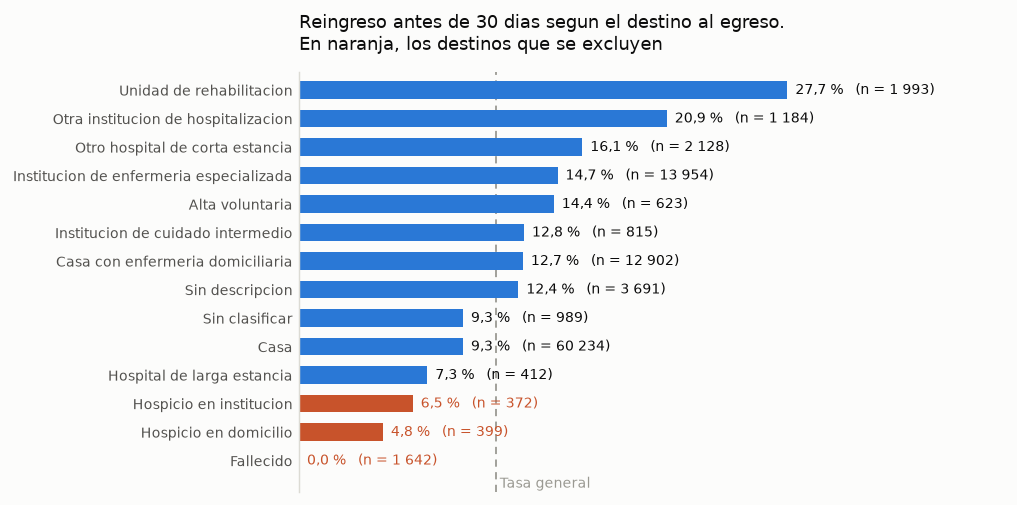

In [25]:
FALLECIDOS = {"11", "19", "20", "21"}
HOSPICIO = {"13", "14"}
EXCLUIDOS = FALLECIDOS | HOSPICIO

# Nombres cortos para los destinos cuya descripcion no cabe en el eje.
CORTOS = {
    "1": "Casa",
    "7": "Alta voluntaria",
    "11": "Fallecido",
    "25": "Sin clasificar",
    "2": "Otro hospital de corta estancia",
    "3": "Institucion de enfermeria especializada",
    "4": "Institucion de cuidado intermedio",
    "5": "Otra institucion de hospitalizacion",
    "6": "Casa con enfermeria domiciliaria",
    "13": "Hospicio en domicilio",
    "14": "Hospicio en institucion",
    "22": "Unidad de rehabilitacion",
    "23": "Hospital de larga estancia",
}

d = por_destino.sort_values("reingreso")
etiquetas = [CORTOS.get(i, t) for i, t in zip(d.index, d["destino"])]
colores = [SERIE_2 if i in EXCLUIDOS else SERIE for i in d.index]

fig, ax = plt.subplots(figsize=(7.0, 4.2))
barras = ax.barh(range(len(d)), d["reingreso"], color=colores, height=0.62, zorder=2)
for b, v, n, i in zip(barras, d["reingreso"], d["registros"], d.index):
    color_txt = SERIE_2 if i in EXCLUIDOS else TINTA
    ax.text(b.get_width() + 0.45, b.get_y() + b.get_height() / 2,
            pct(v) + "   (n = " + f"{n:,}".replace(",", " ") + ")",
            va="center", fontsize=7.5, color=color_txt)

ax.axvline(objetivo.mean() * 100, color=REFERENCIA, linewidth=1,
           linestyle=(0, (4, 3)), zorder=1)
ax.text(objetivo.mean() * 100, -0.95, " Tasa general", fontsize=7.5, color=REFERENCIA)

ax.set_yticks(range(len(d)), etiquetas, fontsize=8)
ax.set_xlim(0, 40)
ax.set_ylim(-1.1, len(d) - 0.35)
ax.set_title("Reingreso antes de 30 dias segun el destino al egreso.\n"
             "En naranja, los destinos que se excluyen",
             fontsize=10, color=TINTA, loc="left", pad=12)
limpiar(ax, horizontal=True)
plt.show()

El destino al egreso discrimina con fuerza. Los pacientes enviados a casa, que son 60 234 y constituyen el grupo mayoritario, reingresan al 9,30 %, por debajo de la tasa general. En el extremo opuesto, los trasladados a unidades de rehabilitación alcanzan 27,70 %.

Los dos destinos marcados en naranja se sitúan por debajo de todos los demás, y por razones que conviene separar.

### 5.2 Pacientes fallecidos

Los códigos 11, 19, 20 y 21 corresponden a pacientes que fallecieron durante la hospitalización o poco después, en distintos contextos de registro.

Estos casos no admiten reingreso. Si aparecieran con tasa distinta de cero, indicaría un error en los datos.

La celda siguiente cuenta los registros y verifica cuántos figuran con reingreso.

In [26]:
es_fallecido = df["discharge_disposition_id"].isin(FALLECIDOS)

print(f"Registros con egreso por fallecimiento : {int(es_fallecido.sum()):,}")
print(f"De ellos, con reingreso antes de 30 dias : {int(objetivo[es_fallecido].sum())}")
print()
for codigo in sorted(FALLECIDOS, key=int):
    n = int((df["discharge_disposition_id"] == codigo).sum())
    if n:
        print(f"  {codigo:>2}  {destinos.get(codigo, ''):<52} {n:>6,}")

Registros con egreso por fallecimiento : 1,652
De ellos, con reingreso antes de 30 dias : 0

  11  Expired                                               1,642
  19  Expired at home. Medicaid only, hospice.                  8
  20  Expired in a medical facility. Medicaid only, hospice.      2


Ninguno de los 1 652 registros presenta reingreso. El dato confirma lo que la definición ya anticipaba.

Conservar estos casos introduciría 1 652 ejemplos negativos cuyo desenlace estaba determinado de antemano. El modelo aprendería a reconocer características asociadas al fallecimiento y a asignarles riesgo bajo de reingreso, lo cual es correcto en términos estadísticos e inútil en términos de la decisión: a un paciente fallecido no se le programa control de seguimiento.

### 5.3 Egreso a hospicio

Los códigos 13 y 14 corresponden a pacientes trasladados a cuidado paliativo, en domicilio o en institución.

A diferencia del caso anterior, aquí el reingreso sí ocurre. La exclusión responde a un motivo distinto, relacionado con el alcance de la decisión que el tablero apoya.

La celda siguiente cuenta los registros y su distribución de desenlaces.

In [27]:
es_hospicio = df["discharge_disposition_id"].isin(HOSPICIO)

print(f"Registros con egreso a hospicio : {int(es_hospicio.sum()):,}")
print()
print(df.loc[es_hospicio, "readmitted"].value_counts()[["<30", ">30", "NO"]].to_string())
print()
print(f"Reingreso antes de 30 dias : {objetivo[es_hospicio].mean() * 100:.2f} %  "
      f"(frente a {objetivo.mean() * 100:.2f} % general)")

Registros con egreso a hospicio : 771

readmitted
<30     43
>30     43
NO     685

Reingreso antes de 30 dias : 5.58 %  (frente a 11.16 % general)


De los 771 registros, 43 presentan reingreso antes de 30 días, lo que equivale a 5,58 %, aproximadamente la mitad de la tasa general. Otros 43 reingresan después de ese plazo.

El reingreso es posible, de modo que la exclusión no corrige un imposible. El motivo es que estos pacientes se encuentran en cuidado de fin de vida, situación en la que programar un control de seguimiento para evitar el reingreso no constituye la intervención pertinente. Predecir su riesgo con precisión no modificaría ninguna decisión del servicio.

### 5.4 Conjunto de trabajo

La celda siguiente aplica ambas exclusiones, construye el conjunto sobre el cual trabajarán las secciones restantes y recalcula la proporción de positivos.

In [28]:
trabajo = df[~df["discharge_disposition_id"].isin(EXCLUIDOS)].copy()
trabajo["objetivo"] = (trabajo["readmitted"] == "<30").astype(int)

salen = len(df) - len(trabajo)

print(f"Conjunto original  : {len(df):>7,} registros   tasa {objetivo.mean() * 100:5.2f} %")
print(f"Excluidos          : {salen:>7,} registros   ({salen / len(df) * 100:.2f} %)")
print(f"  por fallecimiento: {int(es_fallecido.sum()):>7,}")
print(f"  por hospicio     : {int(es_hospicio.sum()):>7,}")
print(f"Conjunto de trabajo: {len(trabajo):>7,} registros   tasa {trabajo['objetivo'].mean() * 100:5.2f} %")
print()
print(f"Pacientes distintos en el conjunto de trabajo : {trabajo['patient_nbr'].nunique():,}")

Conjunto original  : 101,766 registros   tasa 11.16 %


Excluidos          :   2,423 registros   (2.38 %)
  por fallecimiento:   1,652
  por hospicio     :     771
Conjunto de trabajo:  99,343 registros   tasa 11.39 %



Pacientes distintos en el conjunto de trabajo : 69,990


Salen 2 423 registros, el 2,38 % del total. El conjunto de trabajo queda en 99 343 egresos correspondientes a 69 971 pacientes, con una tasa de reingreso temprano de 11,39 %.

La proporción de positivos sube 0,23 puntos respecto del conjunto completo, variación esperable dado que ambos grupos excluidos presentaban tasas inferiores a la general. Los valores calculados en la sección 4 se actualizan en consecuencia: la referencia frente a la cual se evalúa el modelo pasa a ser 11,4 %, y la exactitud del clasificador trivial, 88,6 %.

Las secciones siguientes utilizan `trabajo` en lugar de `df`.

## 6. Exploración de variables

Con el conjunto de trabajo definido, corresponde revisar las variables una por una para establecer cuáles entran al modelo y en qué forma.

En **6.1** se examinan las ocho variables numéricas y la forma de su distribución. En **6.2** se analizan las veintitrés columnas de medicamentos, que comparten codificación y presentan un problema común. En **6.3** se aborda la alta cardinalidad de los códigos de diagnóstico y se propone una agrupación. En **6.4** se consolidan las variables que se descartan.

### 6.1 Variables numéricas

Las ocho columnas convertidas a entero en la sección 1 describen dos cosas distintas: la intensidad del episodio actual, como los días de estancia o el número de medicamentos administrados, y el historial del paciente en el año previo, como las consultas ambulatorias o las hospitalizaciones anteriores.

La celda siguiente reporta los estadísticos descriptivos y el coeficiente de asimetría de cada una.

In [29]:
NUMERICAS = ENTERAS

descriptivos = trabajo[NUMERICAS].describe().T[["mean", "50%", "max"]].round(2)
descriptivos.columns = ["media", "mediana", "maximo"]
descriptivos["asimetria"] = trabajo[NUMERICAS].skew().round(2)
descriptivos

,media,mediana,maximo,asimetria
time_in_hospital,4.38,4.0,14.0,1.14
num_lab_procedures,42.91,44.0,132.0,-0.24
num_procedures,1.33,1.0,6.0,1.32
num_medications,15.98,15.0,81.0,1.34
number_outpatient,0.37,0.0,42.0,8.84
number_emergency,0.20,0.0,76.0,22.85
number_inpatient,0.63,0.0,21.0,3.63
number_diagnoses,7.40,8.0,16.0,-0.86


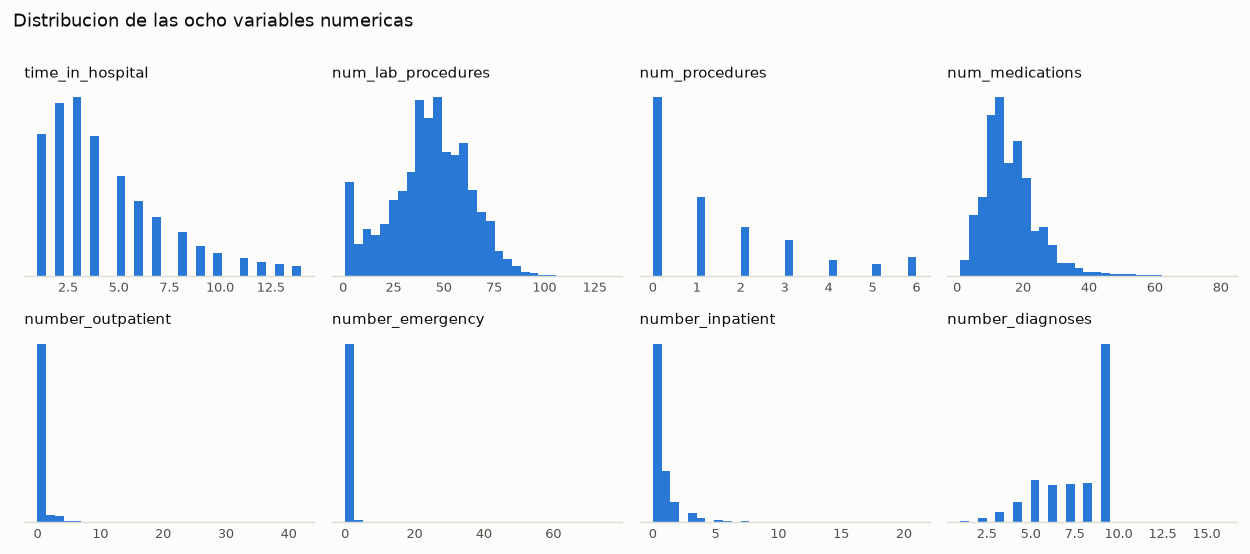

In [30]:
fig, ejes = plt.subplots(2, 4, figsize=(9.6, 4.2))

for ax, col in zip(ejes.ravel(), NUMERICAS):
    ax.hist(trabajo[col], bins=30, color=SERIE, zorder=2)
    ax.set_title(col, fontsize=8.5, color=TINTA, loc="left", pad=6)
    ax.set_yticks([])
    ax.tick_params(labelsize=7)
    limpiar(ax)
    ax.grid(False)

fig.suptitle("Distribucion de las ocho variables numericas",
             fontsize=10, color=TINTA, x=0.005, ha="left", y=1.0)
fig.tight_layout()
plt.show()

Las variables se separan en dos comportamientos.

`time_in_hospital`, `num_lab_procedures`, `num_medications`, `num_procedures` y `number_diagnoses` describen el episodio actual y presentan distribuciones concentradas, con asimetría entre −0,86 y 1,34. La estancia mediana es de 4 días y el número mediano de medicamentos administrados es 15.

`number_outpatient`, `number_emergency` y `number_inpatient` describen el historial del año previo y tienen mediana cero: la mayoría de los pacientes no registra ningún antecedente. Su asimetría es mucho mayor, y alcanza 22,85 en `number_emergency`, donde un registro llega a 76 visitas a urgencias. Distribuciones de esta forma conviene transformarlas o agruparlas por tramos antes de usarlas en modelos sensibles a la escala.

### 6.2 Columnas de medicamentos

Veintitrés columnas registran el manejo de un fármaco durante la hospitalización, con cuatro valores posibles: `Up` si se aumentó la dosis, `Down` si se redujo, `Steady` si se mantuvo y `No` si no se recetó.

Como `No` indica ausencia de prescripción, el número de registros distintos de `No` mide cuántas veces el fármaco aparece efectivamente en los datos.

La celda siguiente calcula ese conteo para las veintitrés columnas y lo representa.

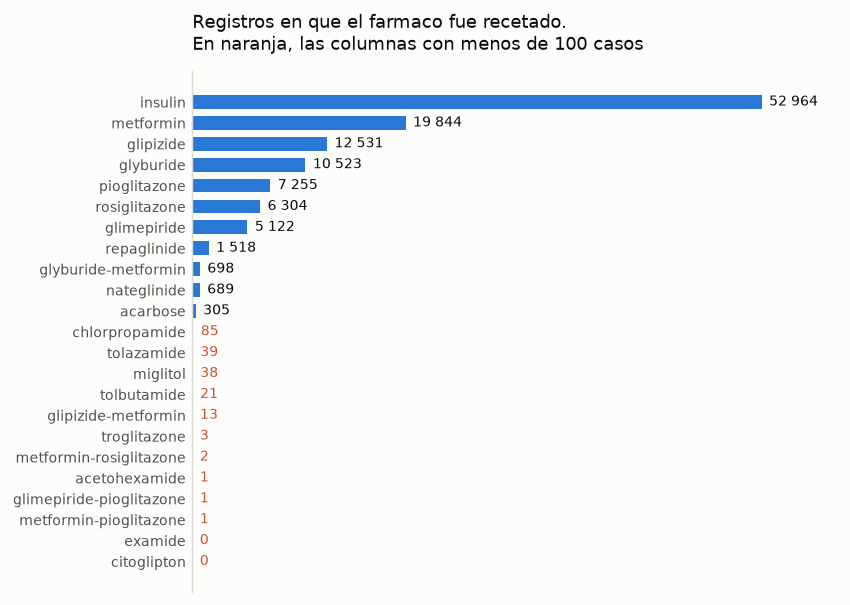

In [31]:
FARMACOS = [c for c in trabajo.columns
            if trabajo[c].dropna().isin(["Up", "Down", "Steady", "No"]).all()
            and trabajo[c].nunique() <= 4 and c not in ("change", "diabetesMed")]

uso = pd.Series({c: int((trabajo[c] != "No").sum()) for c in FARMACOS}).sort_values()

fig, ax = plt.subplots(figsize=(6.4, 5.2))
colores = [SERIE_2 if v < 100 else SERIE for v in uso.values]
barras = ax.barh(range(len(uso)), uso.values, color=colores, height=0.66, zorder=2)
for b, v in zip(barras, uso.values):
    # Con menos de 100 casos la barra es invisible; el color pasa a la etiqueta.
    ax.text(b.get_width() + 700, b.get_y() + b.get_height() / 2,
            f"{v:,}".replace(",", " "), va="center", fontsize=7.5,
            color=SERIE_2 if v < 100 else TINTA)

ax.set_yticks(range(len(uso)), uso.index, fontsize=8)
ax.set_xlim(0, 60000)
ax.set_title("Registros en que el farmaco fue recetado.\n"
             "En naranja, las columnas con menos de 100 casos",
             fontsize=10, color=TINTA, loc="left", pad=12)
limpiar(ax, horizontal=True)
plt.show()

La insulina aparece en 52 964 registros, algo más de la mitad del conjunto. Le siguen metformina con 19 844 y glipizida con 12 531.

En el extremo opuesto, once columnas registran menos de cien casos. `examide` y `citoglipton` no aparecen en ningún registro, de modo que su valor es constante. `acetohexamide`, `glimepiride-pioglitazone` y `metformin-pioglitazone` tienen un solo caso cada una.

Once columnas sobre veintitrés no pueden sostener una estimación. Se descartan y se conserva el resto.

### 6.3 Códigos de diagnóstico

`diag_1`, `diag_2` y `diag_3` contienen códigos ICD-9 y presentan entre 715 y 789 valores distintos, según lo observado en 2.4. Codificarlos directamente produciría más de dos mil variables indicadoras, la mayoría con muy pocos registros.

El sistema ICD-9 organiza los códigos por rangos numéricos que corresponden a categorías clínicas, lo que permite agruparlos. La agrupación empleada es la del artículo original sobre este conjunto de datos, con una salvedad: los códigos que comienzan por letra, 1 632 con `V` y uno con `E`, corresponden a factores externos y de contacto con servicios de salud, y se asignan a la categoría restante.

La celda siguiente define la función de agrupación, la aplica a `diag_1` y calcula la tasa de reingreso por categoría.

In [32]:
def grupo_icd9(codigo):
    """Agrupa un codigo ICD-9 en su categoria clinica."""
    if pd.isna(codigo):
        return "Sin registro"
    codigo = str(codigo)
    if codigo.startswith("250"):
        return "Diabetes"
    if codigo.startswith(("V", "E")):
        return "Otras"

    n = float(codigo)
    if 390 <= n <= 459 or n == 785:
        return "Circulatorio"
    if 460 <= n <= 519 or n == 786:
        return "Respiratorio"
    if 520 <= n <= 579 or n == 787:
        return "Digestivo"
    if 800 <= n <= 999:
        return "Lesiones"
    if 710 <= n <= 739:
        return "Musculoesqueletico"
    if 580 <= n <= 629 or n == 788:
        return "Genitourinario"
    if 140 <= n <= 239:
        return "Neoplasias"
    return "Otras"


trabajo["diag_1_grupo"] = trabajo["diag_1"].map(grupo_icd9)

por_grupo = (trabajo.groupby("diag_1_grupo")
             .agg(registros=("objetivo", "size"), reingreso=("objetivo", "mean")))
por_grupo["reingreso"] = (por_grupo["reingreso"] * 100).round(2)
por_grupo = por_grupo[por_grupo["registros"] >= 100].sort_values("registros", ascending=False)

print(f"{trabajo['diag_1'].nunique()} codigos distintos se reducen a "
      f"{len(por_grupo)} categorias\n")
por_grupo

715 codigos distintos se reducen a 9 categorias



,registros,reingreso
diag_1_grupo,,
Circulatorio,29681,11.69
Otras,17793,11.68
Respiratorio,13934,10.06
Digestivo,9333,10.82
Diabetes,8661,13.10
Lesiones,6853,12.40
Genitourinario,5002,11.04
Musculoesqueletico,4935,9.54
Neoplasias,3131,10.89


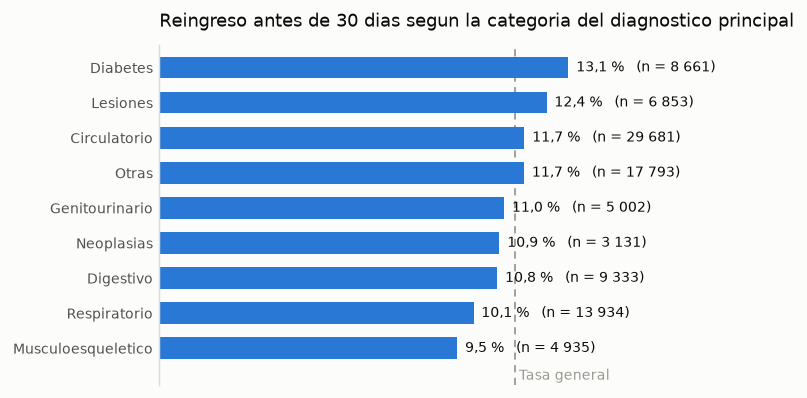

In [33]:
g = por_grupo.sort_values("reingreso")

fig, ax = plt.subplots(figsize=(6.2, 3.4))
barras = ax.barh(range(len(g)), g["reingreso"], color=SERIE, height=0.62, zorder=2)
for b, v, n in zip(barras, g["reingreso"], g["registros"]):
    ax.text(b.get_width() + 0.25, b.get_y() + b.get_height() / 2,
            pct(v) + "   (n = " + f"{n:,}".replace(",", " ") + ")",
            va="center", fontsize=7.5, color=TINTA)

ax.axvline(trabajo["objetivo"].mean() * 100, color=REFERENCIA, linewidth=1,
           linestyle=(0, (4, 3)), zorder=1)
ax.text(trabajo["objetivo"].mean() * 100, -0.9, " Tasa general", fontsize=7.5, color=REFERENCIA)

ax.set_yticks(range(len(g)), g.index, fontsize=8)
ax.set_xlim(0, 20)
ax.set_ylim(-1.05, len(g) - 0.35)
ax.set_title("Reingreso antes de 30 dias segun la categoria del diagnostico principal",
             fontsize=10, color=TINTA, loc="left", pad=10)
limpiar(ax, horizontal=True)
plt.show()

La agrupación reduce 715 códigos a nueve categorías sin perder capacidad discriminante. El diagnóstico principal de diabetes presenta la tasa más alta, 13,10 % sobre 8 661 registros, y el musculoesquelético la más baja, 9,54 %. La diferencia entre ambos extremos es de 3,6 puntos porcentuales sobre una tasa general de 11,39 %.

El grupo circulatorio es el más numeroso, con 29 681 registros y una tasa de 11,69 %, cercana a la general.

La misma función se aplicará a `diag_2` y `diag_3` en el procesamiento.

### 6.4 Variables descartadas

La celda siguiente consolida las columnas que no entran al modelo, con el motivo correspondiente.

In [34]:
constantes = [c for c in FARMACOS if trabajo[c].nunique() == 1]
casi_constantes = [c for c in FARMACOS if 0 < int((trabajo[c] != "No").sum()) < 100]

descartadas = pd.DataFrame(
    [("weight", "Datos ausentes", "96.9 % sin valor y la ausencia no discrimina")]
    + [(c, "Valor constante", "Un unico valor en todo el conjunto") for c in constantes]
    + [(c, "Casi constante", f"{int((trabajo[c] != 'No').sum())} registros con prescripcion")
       for c in casi_constantes]
    + [("encounter_id", "Identificador", "Clave primaria, sin contenido predictivo"),
       ("patient_nbr", "Identificador", "Se usa para agrupar la particion, no como variable"),
       ("readmitted", "Origen del objetivo", "De ella se deriva la variable a predecir")],
    columns=["columna", "motivo", "detalle"])

print(f"{len(descartadas)} columnas descartadas de {trabajo.shape[1] - 2} disponibles\n")
descartadas

16 columnas descartadas de 50 disponibles



,columna,motivo,detalle
0,weight,Datos ausentes,96.9 % sin valor y la ausencia no discrimina
1,examide,Valor constante,Un unico valor en todo el conjunto
2,citoglipton,Valor constante,Un unico valor en todo el conjunto
3,chlorpropamide,Casi constante,85 registros con prescripcion
4,acetohexamide,Casi constante,1 registros con prescripcion
5,tolbutamide,Casi constante,21 registros con prescripcion
6,miglitol,Casi constante,38 registros con prescripcion
7,troglitazone,Casi constante,3 registros con prescripcion
8,tolazamide,Casi constante,39 registros con prescripcion
9,glipizide-metformin,Casi constante,13 registros con prescripcion


Quedan disponibles el resto de columnas, con `race` reservada para el análisis de sesgo por grupo y no como variable predictora, según lo definido en la maqueta.

## 7. Relación con el reingreso

La sección anterior describió cada variable por separado. Corresponde ahora cruzarlas con el objetivo para establecer cuáles separan a quien reingresa de quien no, y con qué intensidad.

Todos los gráficos que siguen comparten la misma construcción: agrupan los registros por los valores de una variable y muestran la tasa de reingreso de cada grupo frente a la tasa general de 11,4 %, marcada con una línea punteada. El tamaño de cada grupo acompaña la cifra, porque una tasa alta sobre pocos registros no es un hallazgo.

En **7.1** se examina el historial del paciente en el año previo. En **7.2**, la intensidad del episodio actual. En **7.3**, la edad. En **7.4**, el servicio que da el alta. En **7.5** se comparan todas las variables según cuánto separan.

Las tres primeras alimentan directamente los elementos E10, E11 y E12 de la maqueta del tablero.

In [35]:
BASE = trabajo["objetivo"].mean() * 100


def tasa_por_tramo(columna, cortes, etiquetas):
    """Agrupa una variable numerica en tramos y calcula tasa de reingreso por tramo."""
    grupos = pd.cut(trabajo[columna], cortes, labels=etiquetas)
    r = trabajo.groupby(grupos, observed=True)["objetivo"].agg(["size", "mean"])
    r["mean"] = r["mean"] * 100
    return r


def barras_tasa(ax, r, titulo, etiqueta_x, tope, destacar=None):
    """Barras verticales de tasa con la linea de referencia y el tamano de cada grupo."""
    barras = ax.bar(range(len(r)), r["mean"], color=SERIE, width=0.62, zorder=2)
    for i, (b, v, n) in enumerate(zip(barras, r["mean"], r["size"])):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + tope * 0.03, pct(v),
                ha="center", fontsize=8, color=TINTA)
        ax.text(b.get_x() + b.get_width() / 2, -tope * 0.12,
                "n = " + f"{int(n):,}".replace(",", " "),
                ha="center", fontsize=6.5, color=TINTA_2)

    ax.axhline(BASE, color=REFERENCIA, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
    ax.set_xticks(range(len(r)), [str(i) for i in r.index], fontsize=8)
    ax.set_ylim(0, tope)
    ax.set_xlabel(etiqueta_x, labelpad=18)
    ax.set_title(titulo, fontsize=9.5, color=TINTA, loc="left", pad=8)
    limpiar(ax)

### 7.1 Historial del paciente en el año previo

Tres columnas registran la actividad del paciente durante los doce meses anteriores al ingreso: hospitalizaciones, visitas a urgencias y consultas ambulatorias. Ninguna describe el episodio actual.

La celda siguiente agrupa las dos primeras por tramos y compara sus tasas.

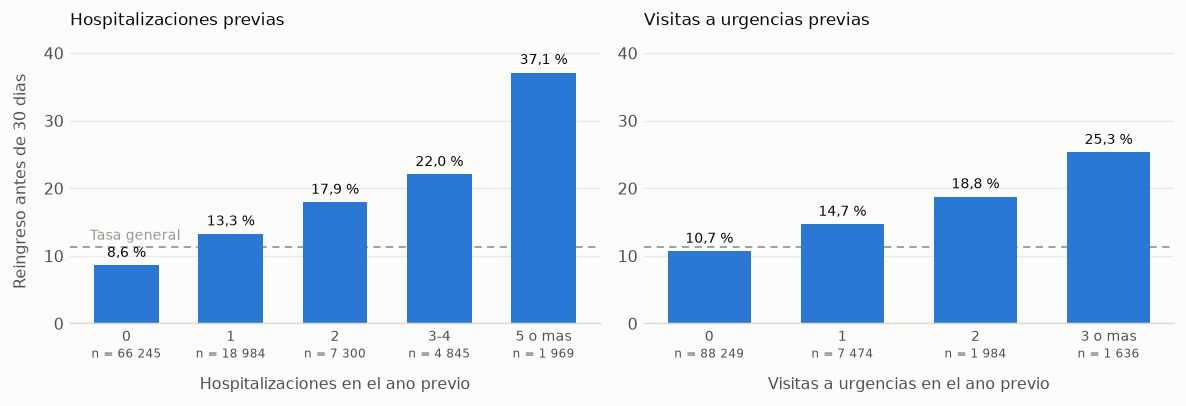

In [36]:
ingresos = tasa_por_tramo("number_inpatient", [-1, 0, 1, 2, 4, 1000],
                          ["0", "1", "2", "3-4", "5 o mas"])
urgencias = tasa_por_tramo("number_emergency", [-1, 0, 1, 2, 1000],
                           ["0", "1", "2", "3 o mas"])

fig, ejes = plt.subplots(1, 2, figsize=(9.2, 3.2))
barras_tasa(ejes[0], ingresos, "Hospitalizaciones previas",
            "Hospitalizaciones en el ano previo", 42)
barras_tasa(ejes[1], urgencias, "Visitas a urgencias previas",
            "Visitas a urgencias en el ano previo", 42)
ejes[0].set_ylabel("Reingreso antes de 30 dias", labelpad=8)
ejes[0].text(-0.35, BASE + 1.0, "Tasa general", ha="left", fontsize=7.5, color=REFERENCIA)
fig.tight_layout()
plt.show()

El número de hospitalizaciones previas produce la separación más marcada de todo el conjunto. Un paciente sin antecedentes reingresa al 8,59 %, por debajo de la tasa general; con cinco o más hospitalizaciones en el año previo, la tasa asciende a 37,13 %, más del cuádruple. La relación es monótona: cada tramo supera al anterior.

Las visitas a urgencias siguen el mismo patrón con menor intensidad, de 10,69 % a 25,31 %.

Dos observaciones sobre el uso de estas variables. La primera es que están disponibles en el momento del alta, de modo que no plantean problemas de temporalidad. La segunda es que ambas concentran la mayoría de los registros en el valor cero, 66 245 y 88 249 respectivamente, lo que explica la asimetría observada en 6.1 y sugiere que la agrupación por tramos empleada aquí es también la forma adecuada de llevarlas al modelo.

### 7.2 Intensidad del episodio actual

La duración de la estancia y el número de medicamentos administrados describen qué tan complejo fue el episodio. La hipótesis a verificar es si una hospitalización más intensa se asocia con mayor reingreso.

La celda siguiente agrupa ambas variables por tramos.

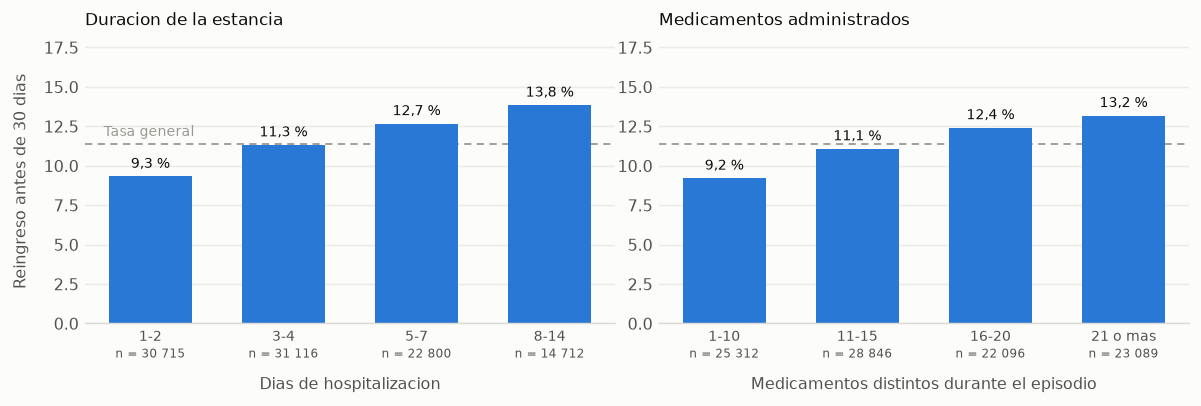

In [37]:
estancia = tasa_por_tramo("time_in_hospital", [0, 2, 4, 7, 14],
                          ["1-2", "3-4", "5-7", "8-14"])
medicamentos = tasa_por_tramo("num_medications", [0, 10, 15, 20, 81],
                              ["1-10", "11-15", "16-20", "21 o mas"])

fig, ejes = plt.subplots(1, 2, figsize=(9.2, 3.2))
barras_tasa(ejes[0], estancia, "Duracion de la estancia", "Dias de hospitalizacion", 18)
barras_tasa(ejes[1], medicamentos, "Medicamentos administrados",
            "Medicamentos distintos durante el episodio", 18)
ejes[0].set_ylabel("Reingreso antes de 30 dias", labelpad=8)
ejes[0].text(-0.35, BASE + 0.5, "Tasa general", ha="left", fontsize=7.5, color=REFERENCIA)
fig.tight_layout()
plt.show()

Ambas relaciones son monótonas y crecientes, pero mucho más débiles que las del historial previo. La estancia va de 9,32 % a 13,85 %, un recorrido de 4,5 puntos, y los medicamentos de 9,21 % a 13,18 %, de 4,0 puntos.

Las dos variables aportan señal y conviene conservarlas, pero por sí solas no sostienen una priorización.

### 7.3 Grupo de edad

`age` viene agrupada en décadas por el propio conjunto de datos, de modo que no requiere tramos adicionales. Es una variable ordinal y conviene preservar ese orden al codificarla.

La celda siguiente calcula la tasa de reingreso por década.

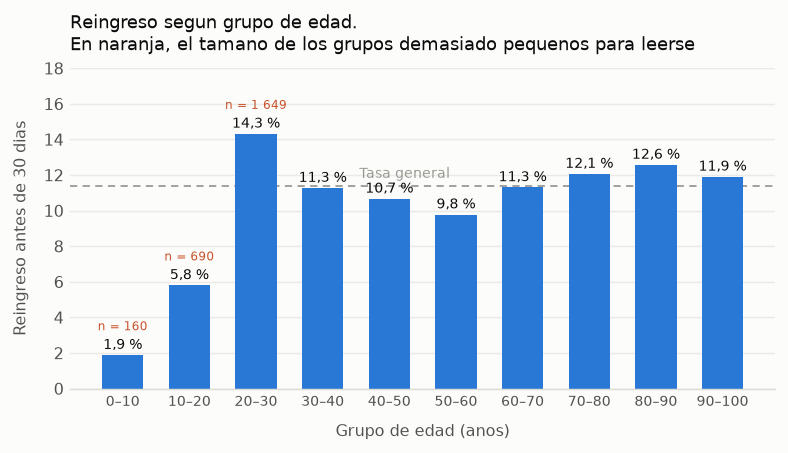

In [38]:
por_edad = trabajo.groupby("age")["objetivo"].agg(["size", "mean"]).sort_index()
por_edad["mean"] = por_edad["mean"] * 100
etiquetas_edad = [i.strip("[)").replace("-", "–") for i in por_edad.index]

fig, ax = plt.subplots(figsize=(7.0, 3.2))
barras = ax.bar(range(len(por_edad)), por_edad["mean"], color=SERIE, width=0.62, zorder=2)
for b, v in zip(barras, por_edad["mean"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.35, pct(v),
            ha="center", fontsize=7.5, color=TINTA)

# Los dos primeros grupos y el pico de 20-30 se apoyan en pocos registros.
for i in (0, 1, 2):
    ax.text(i, por_edad["mean"].iloc[i] + 1.4,
            "n = " + f"{int(por_edad['size'].iloc[i]):,}".replace(",", " "),
            ha="center", fontsize=6.5, color=SERIE_2)

ax.axhline(BASE, color=REFERENCIA, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(3.55, BASE + 0.45, "Tasa general", ha="left", fontsize=7.5, color=REFERENCIA)
ax.set_xticks(range(len(por_edad)), etiquetas_edad, fontsize=8)
ax.set_ylim(0, 18)
ax.set_xlabel("Grupo de edad (anos)", labelpad=8)
ax.set_ylabel("Reingreso antes de 30 dias", labelpad=8)
ax.set_title("Reingreso segun grupo de edad.\n"
             "En naranja, el tamano de los grupos demasiado pequenos para leerse",
             fontsize=10, color=TINTA, loc="left", pad=10)
limpiar(ax)
plt.show()

Entre los 50 y los 90 años la tasa sube de forma sostenida, de 9,77 % a 12,57 %. Es el tramo donde se concentra el 81 % de los registros y donde la lectura es confiable.

Los tres primeros grupos requieren cautela. Los menores de 10 años son 160 registros y los de 10 a 20 son 690, cantidades insuficientes para estimar una tasa. El grupo de 20 a 30 años muestra 14,31 %, el valor más alto de toda la variable, pero se apoya en 1 649 registros y rompe la tendencia de los grupos vecinos, de modo que no debe interpretarse como un hallazgo sin verificación adicional.

### 7.4 Servicio que da el alta

`medical_specialty` identifica la especialidad del médico que admite al paciente. Es la variable que sostiene el elemento E11 de la maqueta, orientado a decidir en qué servicio reforzar la continuidad del cuidado.

Presenta 49,1 % de registros sin valor, según lo establecido en la sección 3, y 73 categorías distintas. La celda siguiente se restringe a las especialidades con al menos 500 registros, para que las tasas sean estimables.

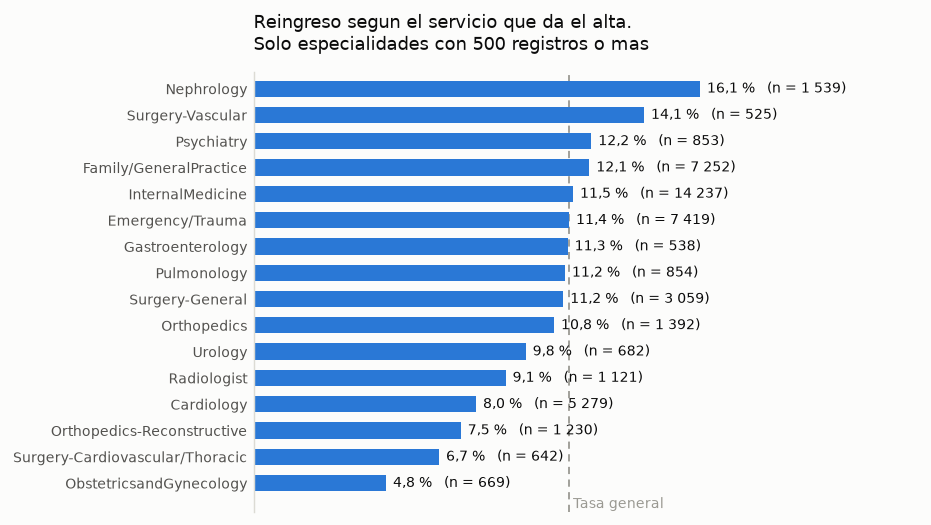

In [39]:
por_servicio = trabajo.groupby("medical_specialty")["objetivo"].agg(["size", "mean"])
por_servicio = por_servicio[por_servicio["size"] >= 500].sort_values("mean")
por_servicio["mean"] = por_servicio["mean"] * 100

fig, ax = plt.subplots(figsize=(6.6, 4.4))
barras = ax.barh(range(len(por_servicio)), por_servicio["mean"],
                 color=SERIE, height=0.62, zorder=2)
for b, v, n in zip(barras, por_servicio["mean"], por_servicio["size"]):
    ax.text(b.get_width() + 0.25, b.get_y() + b.get_height() / 2,
            pct(v) + "   (n = " + f"{int(n):,}".replace(",", " ") + ")",
            va="center", fontsize=7.5, color=TINTA)

ax.axvline(BASE, color=REFERENCIA, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(BASE, -0.95, " Tasa general", fontsize=7.5, color=REFERENCIA)
ax.set_yticks(range(len(por_servicio)), por_servicio.index, fontsize=8)
ax.set_xlim(0, 24)
ax.set_ylim(-1.1, len(por_servicio) - 0.35)
ax.set_title("Reingreso segun el servicio que da el alta.\n"
             "Solo especialidades con 500 registros o mas",
             fontsize=10, color=TINTA, loc="left", pad=12)
limpiar(ax, horizontal=True)
plt.show()

La diferencia entre servicios es sustancial. Nefrología presenta 16,11 % sobre 1 539 registros y cirugía vascular 14,10 %, mientras que ginecología y obstetricia registra 4,78 % y cirugía cardiovascular 6,70 %. Entre el extremo superior y el inferior median 11,3 puntos porcentuales.

Medicina interna, con 14 237 registros, es el servicio con mayor volumen y se sitúa en 11,53 %, cerca de la tasa general.

La lectura de este gráfico corresponde a una decisión distinta de la que apoya el resto del tablero. No indica a qué paciente atender primero, sino en qué servicio conviene reforzar el proceso de alta, y no requiere predecir ningún caso individual.

### 7.5 Comparación entre variables

Para ordenar los hallazgos conviene una medida común. La amplitud —la diferencia entre la tasa del grupo más alto y la del más bajo— indica cuánto separa cada variable, aunque no sustituye la medición de importancia que se obtendrá al entrenar los modelos.

La celda siguiente calcula la amplitud de cada variable examinada y las ordena.

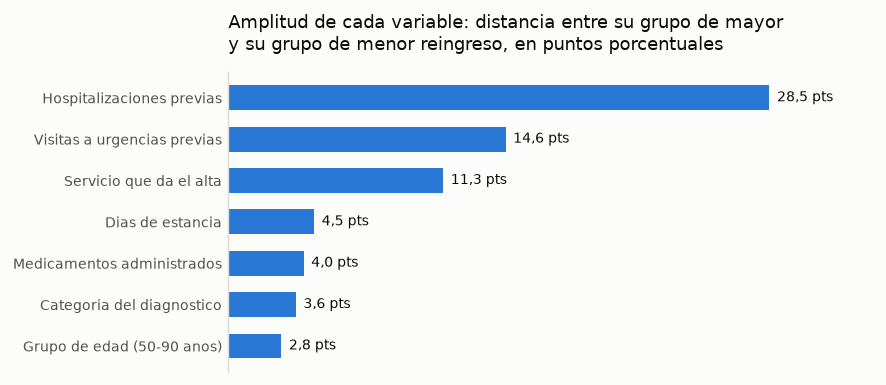

In [40]:
examinadas = {
    "Hospitalizaciones previas": ingresos["mean"],
    "Visitas a urgencias previas": urgencias["mean"],
    "Servicio que da el alta": por_servicio["mean"],
    "Grupo de edad (50-90 anos)": por_edad["mean"].iloc[5:],
    "Categoria del diagnostico": por_grupo["reingreso"],
    "Dias de estancia": estancia["mean"],
    "Medicamentos administrados": medicamentos["mean"],
}

amplitudes = pd.Series({k: v.max() - v.min() for k, v in examinadas.items()}).sort_values()

fig, ax = plt.subplots(figsize=(6.4, 3.0))
barras = ax.barh(range(len(amplitudes)), amplitudes.values, color=SERIE,
                 height=0.6, zorder=2)
for b, v in zip(barras, amplitudes.values):
    ax.text(b.get_width() + 0.4, b.get_y() + b.get_height() / 2,
            f"{v:.1f}".replace(".", ",") + " pts", va="center", fontsize=7.5, color=TINTA)

ax.set_yticks(range(len(amplitudes)), amplitudes.index, fontsize=8)
ax.set_xlim(0, 34)
ax.set_title("Amplitud de cada variable: distancia entre su grupo de mayor\n"
             "y su grupo de menor reingreso, en puntos porcentuales",
             fontsize=10, color=TINTA, loc="left", pad=12)
limpiar(ax, horizontal=True)
plt.show()

El historial previo del paciente domina. Las hospitalizaciones del año anterior separan 28,5 puntos porcentuales, el doble que la siguiente variable, y las visitas a urgencias 14,6 puntos. Ambas describen al paciente antes de llegar, no lo ocurrido durante la hospitalización.

El servicio que da el alta separa 11,3 puntos y la edad, restringida al tramo de lectura confiable, 2,8 puntos.

Las variables del episodio actual quedan al final: la estancia separa 4,5 puntos, los medicamentos 4,0 y la categoría del diagnóstico 3,6.

La conclusión orienta el modelado. Lo que mejor anticipa el reingreso temprano no es la complejidad del episodio sino la trayectoria previa del paciente. Conviene que las variables de historial entren al modelo en la forma que mejor las represente, lo que refuerza la agrupación por tramos propuesta en 7.1.

## 8. Riesgos de fuga

Se denomina fuga a la situación en que el modelo accede, durante el entrenamiento, a información que no estará disponible en el momento de usarlo. El efecto es un desempeño alto en evaluación que no se reproduce en operación.

En este conjunto hay tres fuentes posibles. En **8.1** se cuantifica la que plantean los pacientes con varios encuentros. En **8.2** se revisa la disponibilidad temporal de las variables. En **8.3** se identifican las columnas derivadas del objetivo.

### 8.1 Pacientes con varios encuentros

La sección 2 estableció que el 46 % de las filas corresponde a pacientes que aparecen más de una vez. Una partición aleatoria por filas ubicaría encuentros del mismo paciente en entrenamiento y en evaluación simultáneamente.

La celda siguiente compara dos formas de partir los datos: la aleatoria habitual y una que agrupa por paciente.

In [41]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# Particion aleatoria por fila, la opcion por defecto.
tr, te = train_test_split(trabajo, test_size=0.2, random_state=42,
                          stratify=trabajo["objetivo"])
compartidos = set(tr["patient_nbr"]) & set(te["patient_nbr"])
afectadas = int(te["patient_nbr"].isin(compartidos).sum())

# Particion agrupada: ningun paciente puede quedar a ambos lados.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
i_tr, i_te = next(gss.split(trabajo, groups=trabajo["patient_nbr"]))

print("Particion aleatoria por fila")
print(f"  Pacientes presentes en ambos conjuntos : {len(compartidos):,}")
print(f"  Filas de evaluacion afectadas          : {afectadas:,} "
      f"({afectadas / len(te) * 100:.1f} %)")
print()
print("Particion agrupada por paciente")
print(f"  Pacientes presentes en ambos conjuntos : "
      f"{len(set(trabajo.iloc[i_tr]['patient_nbr']) & set(trabajo.iloc[i_te]['patient_nbr']))}")
print(f"  Tasa de reingreso  entrenamiento {trabajo.iloc[i_tr]['objetivo'].mean() * 100:.2f} %  "
      f"evaluacion {trabajo.iloc[i_te]['objetivo'].mean() * 100:.2f} %")

Particion aleatoria por fila
  Pacientes presentes en ambos conjuntos : 6,798
  Filas de evaluacion afectadas          : 8,249 (41.5 %)

Particion agrupada por paciente
  Pacientes presentes en ambos conjuntos : 0
  Tasa de reingreso  entrenamiento 11.45 %  evaluacion 11.13 %


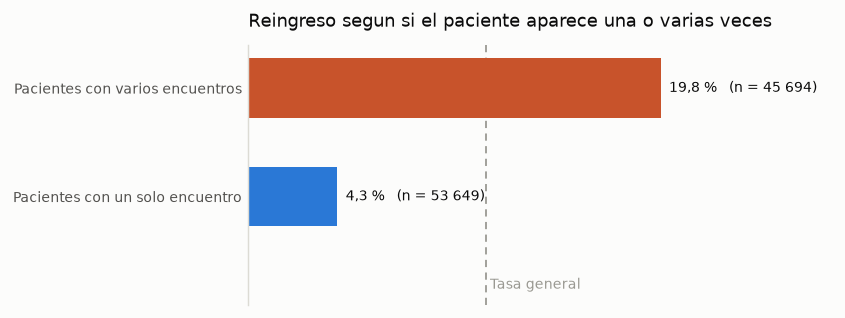

In [42]:
repetidos = trabajo["patient_nbr"].map(trabajo["patient_nbr"].value_counts()) > 1

comparacion_pacientes = pd.Series({
    "Pacientes con un solo encuentro": trabajo.loc[~repetidos, "objetivo"].mean() * 100,
    "Pacientes con varios encuentros": trabajo.loc[repetidos, "objetivo"].mean() * 100,
})

fig, ax = plt.subplots(figsize=(5.8, 2.6))
barras = ax.barh(range(2), comparacion_pacientes.values, color=[SERIE, SERIE_2],
                 height=0.55, zorder=2)
for b, v, n in zip(barras, comparacion_pacientes.values,
                   [int((~repetidos).sum()), int(repetidos.sum())]):
    ax.text(b.get_width() + 0.4, b.get_y() + b.get_height() / 2,
            pct(v) + "   (n = " + f"{n:,}".replace(",", " ") + ")",
            va="center", fontsize=8, color=TINTA)

ax.axvline(BASE, color=REFERENCIA, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(BASE, -0.85, " Tasa general", fontsize=7.5, color=REFERENCIA)
ax.set_yticks(range(2), comparacion_pacientes.index, fontsize=8)
ax.set_xlim(0, 28)
ax.set_ylim(-1.0, 1.4)
ax.set_title("Reingreso segun si el paciente aparece una o varias veces",
             fontsize=10, color=TINTA, loc="left", pad=10)
limpiar(ax, horizontal=True)
plt.show()

La partición aleatoria deja 6 798 pacientes a ambos lados, lo que compromete 8 249 filas de evaluación, el 41,5 % del conjunto de prueba. La partición agrupada deja cero y mantiene tasas de reingreso equivalentes en ambos lados, 11,45 % y 11,13 %.

El gráfico explica por qué la diferencia importa tanto. Los pacientes que aparecen una sola vez reingresan al 4,26 %; los que aparecen varias veces, al 19,76 %. La brecha es de casi cinco veces.

La razón es que el hecho de aparecer varias veces contiene, en buena medida, la respuesta. Si un paciente reingresa antes de 30 días, ese reingreso genera un segundo registro en el conjunto. Reconocer al paciente equivale entonces a conocer el desenlace, y un modelo entrenado con partición aleatoria obtendría un desempeño elevado sin capacidad predictiva real.

De aquí se derivan dos reglas. La partición debe agruparse por `patient_nbr`, y ni ese identificador ni ninguna variable derivada del número de registros del paciente pueden entrar al modelo.

### 8.2 Disponibilidad de las variables en el momento del alta

El modelo se ejecuta antes de que el paciente salga del hospital. Toda variable que requiera información posterior a ese momento resulta inutilizable, con independencia de su capacidad predictiva.

La celda siguiente clasifica las columnas según el momento en que su valor queda determinado.

In [43]:
momentos = pd.DataFrame([
    ("Historial del ano previo", "number_outpatient, number_emergency, number_inpatient",
     "Antes del ingreso", "Disponible"),
    ("Datos del ingreso", "age, gender, race, admission_type_id, admission_source_id",
     "Al ingresar", "Disponible"),
    ("Curso de la hospitalizacion",
     "time_in_hospital, num_lab_procedures, num_medications, diag_1 a diag_3",
     "Durante la estancia", "Disponible"),
    ("Examenes de laboratorio", "A1Cresult, max_glu_serum",
     "Durante la estancia", "Disponible"),
    ("Manejo de farmacos", "insulin, metformin y demas", "Durante la estancia", "Disponible"),
    ("Destino al egreso", "discharge_disposition_id", "Al dar el alta", "Disponible"),
    ("Desenlace", "readmitted", "Despues del alta", "No disponible"),
], columns=["grupo", "columnas", "momento", "estado"])

momentos

,grupo,columnas,momento,estado
0,Historial del ano previo,"number_outpatient, number_emergency, number_in...",Antes del ingreso,Disponible
1,Datos del ingreso,"age, gender, race, admission_type_id, admissio...",Al ingresar,Disponible
2,Curso de la hospitalizacion,"time_in_hospital, num_lab_procedures, num_medi...",Durante la estancia,Disponible
3,Examenes de laboratorio,"A1Cresult, max_glu_serum",Durante la estancia,Disponible
4,Manejo de farmacos,"insulin, metformin y demas",Durante la estancia,Disponible
5,Destino al egreso,discharge_disposition_id,Al dar el alta,Disponible
6,Desenlace,readmitted,Despues del alta,No disponible


Todas las variables del conjunto, salvo `readmitted`, quedan determinadas antes o durante la hospitalización. El destino al egreso se conoce en el momento mismo del alta, que es cuando se ejecuta la predicción, de modo que su uso es admisible.

El formulario de la Pantalla 2 de la maqueta respeta esta restricción: ninguno de los diez campos que solicita requiere información posterior al alta.

### 8.3 Columnas derivadas del objetivo

`readmitted` es la columna de la cual se deriva la variable a predecir y no puede figurar entre las predictoras. La celda siguiente verifica que ninguna otra columna reproduzca el objetivo.

In [44]:
candidatas = [c for c in trabajo.columns
              if c not in ("readmitted", "objetivo", "encounter_id", "patient_nbr")]

sospechosas = []
for col in candidatas:
    tabla = pd.crosstab(trabajo[col], trabajo["objetivo"], normalize="index")
    if 1 in tabla.columns:
        extremos = tabla[1][(tabla[1] == 0) | (tabla[1] == 1)]
        for valor in extremos.index:
            n = int((trabajo[col] == valor).sum())
            if n >= 100:
                sospechosas.append((col, valor, n, round(extremos[valor] * 100, 1)))

if sospechosas:
    print(pd.DataFrame(sospechosas,
                       columns=["columna", "valor", "registros", "reingreso"]).to_string(index=False))
else:
    print("Ninguna columna con 100 registros o mas determina el objetivo por si sola.")

Ninguna columna con 100 registros o mas determina el objetivo por si sola.


Ninguna columna reproduce el objetivo. La única fuente de fuga en este conjunto es la identidad del paciente, tratada en 8.1.

## 9. Decisiones para el pipeline

Consolidación de lo establecido en las ocho secciones anteriores. Cada decisión indica la sección que la sustenta.

### 9.1 Filas

| Decisión | Registros | Sección |
|---|--:|---|
| Excluir egreso por fallecimiento (11, 19, 20, 21) | −1 652 | 5.2 |
| Excluir egreso a hospicio (13, 14) | −771 | 5.3 |
| **Conjunto de trabajo** | **99 343** | 5.4 |

Tasa de reingreso temprano resultante: **11,39 %**, sobre 69 971 pacientes.

### 9.2 Columnas

| Decisión | Columnas | Sección |
|---|---|---|
| Descartar por datos ausentes | `weight` (96,9 % sin valor) | 3.4 |
| Descartar por valor constante | `examide`, `citoglipton` | 6.2 |
| Descartar por menos de 100 casos | 9 columnas de fármaco | 6.2 |
| Descartar por ser identificador | `encounter_id` | 8.1 |
| Reservar para el análisis de sesgo, no como predictora | `race` | maqueta |
| Reservar para agrupar la partición, no como predictora | `patient_nbr` | 8.1 |
| Origen del objetivo, fuera de las predictoras | `readmitted` | 8.3 |

El resto de columnas se conserva.

### 9.3 Transformaciones

| Variable | Transformación | Sección |
|---|---|---|
| `A1Cresult`, `max_glu_serum` | `None` entra como categoría, no se imputa | 3.3 |
| `medical_specialty`, `payer_code`, `diag_1` a `diag_3` | La ausencia entra como categoría propia | 3.4 |
| `diag_1`, `diag_2`, `diag_3` | Agrupar a 9 categorías ICD-9 con `grupo_icd9()` | 6.3 |
| `number_inpatient` | Tramos 0 / 1 / 2 / 3-4 / 5 o más | 7.1 |
| `number_emergency` | Tramos 0 / 1 / 2 / 3 o más | 7.1 |
| `number_outpatient` | Tramos, por la misma asimetría | 6.1 |
| `age` | Ordinal: conservar el orden de las décadas | 7.3 |
| `admission_type_id`, `discharge_disposition_id`, `admission_source_id` | Nominal: el orden numérico no significa nada | 2.4 |

Ninguna variable se imputa. Todos los valores ausentes se representan como categoría.

### 9.4 Partición y evaluación

| Decisión | Valor | Sección |
|---|---|---|
| Partición | `GroupShuffleSplit` agrupando por `patient_nbr` | 8.1 |
| Motivo | La partición aleatoria compromete el 41,5 % de las filas de evaluación | 8.1 |
| Métrica descartada | Exactitud: el clasificador trivial alcanza 88,6 % | 4.3 |
| Métrica principal | Reingresos efectivos entre los primeros k del listado | 4.3 |
| Métrica de respaldo | Área bajo la curva de precisión y exhaustividad | 4.3 |
| Referencia | 11,4 reingresos por cada 100 pacientes elegidos al azar | 4.3 |

### 9.5 Orientación para el modelado

El historial previo del paciente separa más que cualquier característica del episodio actual: 28,5 puntos porcentuales las hospitalizaciones del año anterior, frente a 4,5 de la duración de la estancia. Conviene que esas variables entren al modelo en la forma que mejor las represente.

El servicio que da el alta separa 11,3 puntos y sostiene una decisión distinta —dónde reforzar el proceso de alta— que no requiere predecir casos individuales.

Queda pendiente de verificación en la semana 4 si `medical_specialty` justifica su presencia en el formulario de la Pantalla 2, dado que falta en el 48,9 % de los registros. La comparación se hará entre un modelo con todas las variables disponibles y uno restringido a los diez campos del formulario, y quedará registrada en MLflow.